In [2]:
"""
EXERCICE 4 : Régression linéaire, régularisation & interprétation
================================================================
Objectif : Maîtriser Ridge/Lasso, le chemin de régularisation,
les features polynomiales, et l'interprétation des coefficients.

Ce que vous allez apprendre :
- L'impact de la régularisation sur les coefficients
- Le chemin de régularisation (alpha path)
- Combiner PolynomialFeatures + régularisation
- Interpréter les résultats et diagnostiquer le modèle

Temps estimé : 30 minutes
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, 
    RidgeCV, LassoCV
)
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# =============================================================
# PARTIE 1 : DONNÉES SYNTHÉTIQUES ACTUARIELLES
# =============================================================
print("=" * 60)
print("PARTIE 1 : Création du dataset")
print("=" * 60)

# Simuler un problème de coût sinistre
# Le vrai modèle est NON-LINÉAIRE (mais on ne le sait pas a priori)
np.random.seed(42)
n = 500

# Features
age = np.random.uniform(18, 80, n)
bonus_malus = np.random.uniform(50, 200, n)
anciennete = np.random.uniform(0, 30, n)
densite = np.random.uniform(1, 5000, n)  # Densité de population

# Vraie relation (inconnue du modélisateur)
# Non-linéaire en âge, interaction age × bonus_malus
cout_sinistre = (
    200 
    + 5 * age 
    - 0.08 * age**2               # Effet non-linéaire de l'âge
    + 3 * bonus_malus 
    + 0.02 * age * bonus_malus    # Interaction
    - 2 * anciennete 
    + 0.01 * densite
    + np.random.normal(0, 100, n)  # Bruit
)

X = pd.DataFrame({
    'age': age,
    'bonus_malus': bonus_malus,
    'anciennete': anciennete,
    'densite': densite
})
y = cout_sinistre

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train : {X_train.shape[0]} observations, {X_train.shape[1]} features")
print(f"Test  : {X_test.shape[0]} observations")
print(f"\nStatistiques de la target :")
print(f"  Moyenne : {y.mean():.1f}")
print(f"  Std     : {y.std():.1f}")
print(f"  Min/Max : [{y.min():.1f}, {y.max():.1f}]")

PARTIE 1 : Création du dataset
Train : 350 observations, 4 features
Test  : 150 observations

Statistiques de la target :
  Moyenne : 708.0
  Std     : 202.5
  Min/Max : [164.3, 1252.7]


In [4]:
# =============================================================
# PARTIE 2 : COMPARAISON OLS, RIDGE, LASSO
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Comparaison OLS vs Ridge vs Lasso")
print("=" * 60)

# Toujours scaler pour Ridge/Lasso
models = {
    'OLS (pas de régularisation)': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge (α=0.1)': make_pipeline(StandardScaler(), Ridge(alpha=0.1)),
    'Ridge (α=1.0)': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Ridge (α=100)': make_pipeline(StandardScaler(), Ridge(alpha=100)),
    'Lasso (α=0.1)': make_pipeline(StandardScaler(), Lasso(alpha=0.1)),
    'Lasso (α=1.0)': make_pipeline(StandardScaler(), Lasso(alpha=1.0)),
    'Lasso (α=100)': make_pipeline(StandardScaler(), Lasso(alpha=100)),
}

print(f"\n{'Modèle':<35} {'R² Train':<12} {'R² Test':<12} {'MSE Test'}")
print("-" * 75)

for name, model in models.items():
    model.fit(X_train, y_train)
    r2_train = model.score(X_train, y_train)
    r2_test = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, model.predict(X_test))
    print(f"{name:<35} {r2_train:<12.4f} {r2_test:<12.4f} {mse:.1f}")

# TODO : Observez :
# 1. L'OLS est-il le meilleur sur le test ? Pourquoi ou pourquoi pas ?
# 2. Que se passe-t-il quand α est très grand ?
# 3. Le Lasso avec α=100 a-t-il éliminé des features ?

# Vérifier les coefficients du Lasso fort
lasso_strong = make_pipeline(StandardScaler(), Lasso(alpha=100))
lasso_strong.fit(X_train, y_train)
coefs = pd.Series(lasso_strong.named_steps['lasso'].coef_, index=X.columns)
print(f"\nCoefficients Lasso (α=100) :")
print(coefs)
print(f"Features éliminées (coef=0) : {(coefs == 0).sum()}")


PARTIE 2 : Comparaison OLS vs Ridge vs Lasso

Modèle                              R² Train     R² Test      MSE Test
---------------------------------------------------------------------------
OLS (pas de régularisation)         0.7609       0.7220       10153.2
Ridge (α=0.1)                       0.7609       0.7221       10151.8
Ridge (α=1.0)                       0.7609       0.7224       10139.6
Ridge (α=100)                       0.7237       0.7096       10607.6
Lasso (α=0.1)                       0.7609       0.7221       10151.1
Lasso (α=1.0)                       0.7608       0.7225       10134.9
Lasso (α=100)                       0.5149       0.5186       17583.1

Coefficients Lasso (α=100) :
age             0.000000
bonus_malus    79.160006
anciennete     -0.000000
densite         0.000000
dtype: float64
Features éliminées (coef=0) : 3



PARTIE 3 : Chemin de régularisation


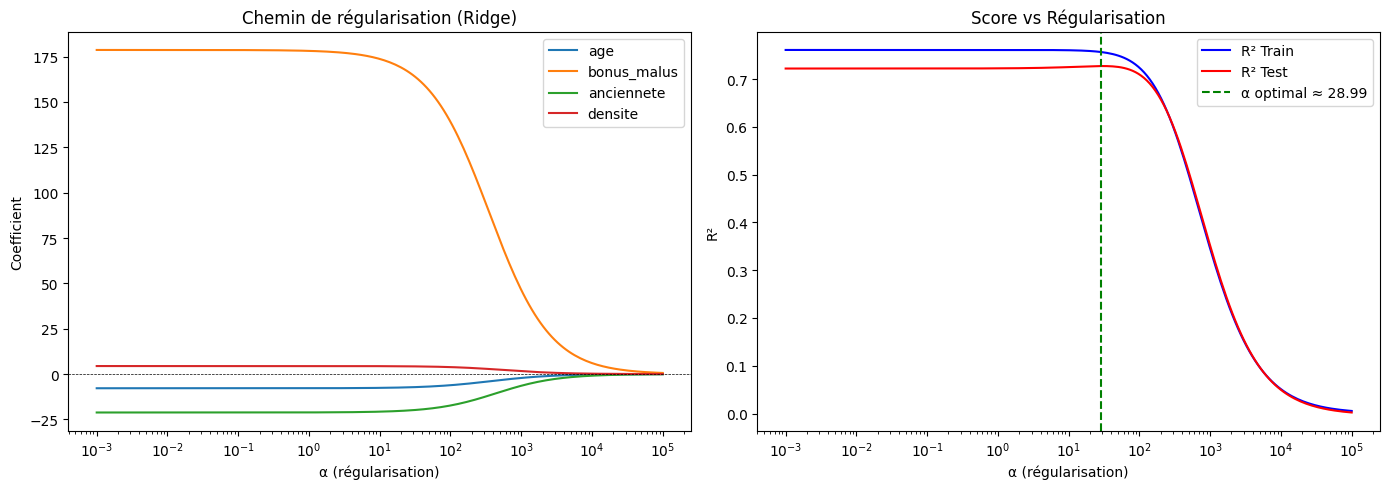

α optimal (meilleur R² test) : 28.9942
R² test correspondant        : 0.7272


In [5]:
# =============================================================
# PARTIE 3 : CHEMIN DE RÉGULARISATION (RIDGE)
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : Chemin de régularisation")
print("=" * 60)

# Scaler d'abord
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = np.logspace(-3, 5, 200)
ridge_coefs = []
ridge_train_scores = []
ridge_test_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    ridge_train_scores.append(ridge.score(X_train_scaled, y_train))
    ridge_test_scores.append(ridge.score(X_test_scaled, y_test))

ridge_coefs = np.array(ridge_coefs)

# Graphique 1 : Chemin de régularisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, feature in enumerate(X.columns):
    ax1.plot(alphas, ridge_coefs[:, i], label=feature)
ax1.set_xscale('log')
ax1.set_xlabel('α (régularisation)')
ax1.set_ylabel('Coefficient')
ax1.set_title('Chemin de régularisation (Ridge)')
ax1.legend()
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Graphique 2 : Score vs alpha
ax2.plot(alphas, ridge_train_scores, 'b-', label='R² Train')
ax2.plot(alphas, ridge_test_scores, 'r-', label='R² Test')
ax2.set_xscale('log')
ax2.set_xlabel('α (régularisation)')
ax2.set_ylabel('R²')
ax2.set_title('Score vs Régularisation')
ax2.legend()

# Marquer le alpha optimal
best_alpha_idx = np.argmax(ridge_test_scores)
ax2.axvline(x=alphas[best_alpha_idx], color='green', linestyle='--', 
            label=f'α optimal ≈ {alphas[best_alpha_idx]:.2f}')
ax2.legend()

plt.tight_layout()
plt.savefig("regularization_path.png", dpi=150)
plt.show()

print(f"α optimal (meilleur R² test) : {alphas[best_alpha_idx]:.4f}")
print(f"R² test correspondant        : {ridge_test_scores[best_alpha_idx]:.4f}")

### 1) Impact sur les coefficients (chemin de régularisation)
- Quand **α augmente**, les coefficients Ridge sont **progressivement contractés vers 0**.
- Les variables les plus stables (coefficients qui restent non nuls plus longtemps) semblent porter un signal plus robuste.
- Contrairement au Lasso, Ridge **ne met pas exactement les coefficients à 0** : il réduit l’amplitude sans faire de vraie sélection de variables.

### 2) Impact sur la performance (R² train vs R² test)
- Le **R² train diminue** quand α augmente (comportement attendu : plus de biais).
- Le **R² test** s’améliore d’abord légèrement (réduction de variance / overfitting), puis finit par se dégrader si α devient trop grand (sous-apprentissage).
- On observe donc un **compromis biais-variance** avec un **α optimal** (celui marqué en vert sur le graphique).

### 3) Lecture pratique
- **α trop faible** : modèle trop flexible, risque de sur-ajustement.
- **α trop fort** : coefficients trop écrasés, perte d’information.
- La bonne pratique est de retenir l’α qui maximise la performance de généralisation (test/CV), pas celui qui maximise le score train.

In [6]:
# =============================================================
# PARTIE 4 : FEATURES POLYNOMIALES + RÉGULARISATION
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Features polynomiales + régularisation")
print("=" * 60)

degrees = [1, 2, 3, 4, 5]
results_poly = []

for degree in degrees:
    # Sans régularisation
    pipe_ols = make_pipeline(PolynomialFeatures(degree, include_bias=False), 
                             StandardScaler(), LinearRegression())
    scores_ols = cross_val_score(pipe_ols, X_train, y_train, cv=5, scoring='r2')
    
    # Avec Ridge
    pipe_ridge = make_pipeline(PolynomialFeatures(degree, include_bias=False), 
                               StandardScaler(), Ridge(alpha=1.0))
    scores_ridge = cross_val_score(pipe_ridge, X_train, y_train, cv=5, scoring='r2')
    
    n_features = PolynomialFeatures(degree, include_bias=False).fit_transform(X_train).shape[1]
    
    results_poly.append({
        'Degré': degree,
        'N features': n_features,
        'R² CV (OLS)': f"{scores_ols.mean():.4f} ± {scores_ols.std():.4f}",
        'R² CV (Ridge)': f"{scores_ridge.mean():.4f} ± {scores_ridge.std():.4f}",
    })

results_df = pd.DataFrame(results_poly)
print(results_df.to_string(index=False))

# TODO : Observez :
# 1. Le degré 2 améliore-t-il le R² par rapport au degré 1 ? (oui, car relation non-linéaire)
# 2. À partir de quel degré l'OLS commence-t-il à overfitter ?
# 3. Ridge stabilise-t-il les performances pour les degrés élevés ?
# 4. Quel est le meilleur compromis degré × régularisation ?


PARTIE 4 : Features polynomiales + régularisation
 Degré  N features     R² CV (OLS)   R² CV (Ridge)
     1           4 0.7390 ± 0.0893 0.7390 ± 0.0889
     2          14 0.7560 ± 0.0667 0.7573 ± 0.0695
     3          34 0.7441 ± 0.0617 0.7543 ± 0.0658
     4          69 0.6545 ± 0.0421 0.7494 ± 0.0660
     5         125 0.5831 ± 0.1022 0.7425 ± 0.0656


In [7]:
# =============================================================
# PARTIE 5 : SÉLECTION AUTOMATIQUE AVEC RidgeCV / LassoCV
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 5 : Sélection automatique de α")
print("=" * 60)

# Le meilleur modèle : degré 2 + Ridge avec alpha optimal
best_pipe = make_pipeline(
    PolynomialFeatures(2, include_bias=False),
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
)
best_pipe.fit(X_train, y_train)

ridge_final = best_pipe.named_steps['ridgecv']
print(f"α optimal sélectionné par CV : {ridge_final.alpha_:.4f}")
print(f"R² train : {best_pipe.score(X_train, y_train):.4f}")
print(f"R² test  : {best_pipe.score(X_test, y_test):.4f}")

# Coefficients (sur features polynomiales)
poly = best_pipe.named_steps['polynomialfeatures']
feature_names_poly = poly.get_feature_names_out(X.columns)
coefs_final = pd.Series(ridge_final.coef_, index=feature_names_poly)
top_coefs = coefs_final.abs().sort_values(ascending=False).head(10)
print(f"\nTop 10 features (par magnitude du coefficient) :")
for feat, val in top_coefs.items():
    print(f"  {feat:<30} : {coefs_final[feat]:+.2f}")



PARTIE 5 : Sélection automatique de α
α optimal sélectionné par CV : 1.6298
R² train : 0.7899
R² test  : 0.7117

Top 10 features (par magnitude du coefficient) :
  age^2                          : -130.69
  bonus_malus                    : +117.53
  age                            : +71.73
  age bonus_malus                : +71.04
  age anciennete                 : -32.96
  age densite                    : +31.31
  anciennete                     : +13.67
  anciennete densite             : -12.99
  densite^2                      : -12.27
  bonus_malus densite            : +11.36



PARTIE 6 : Diagnostic par les résidus


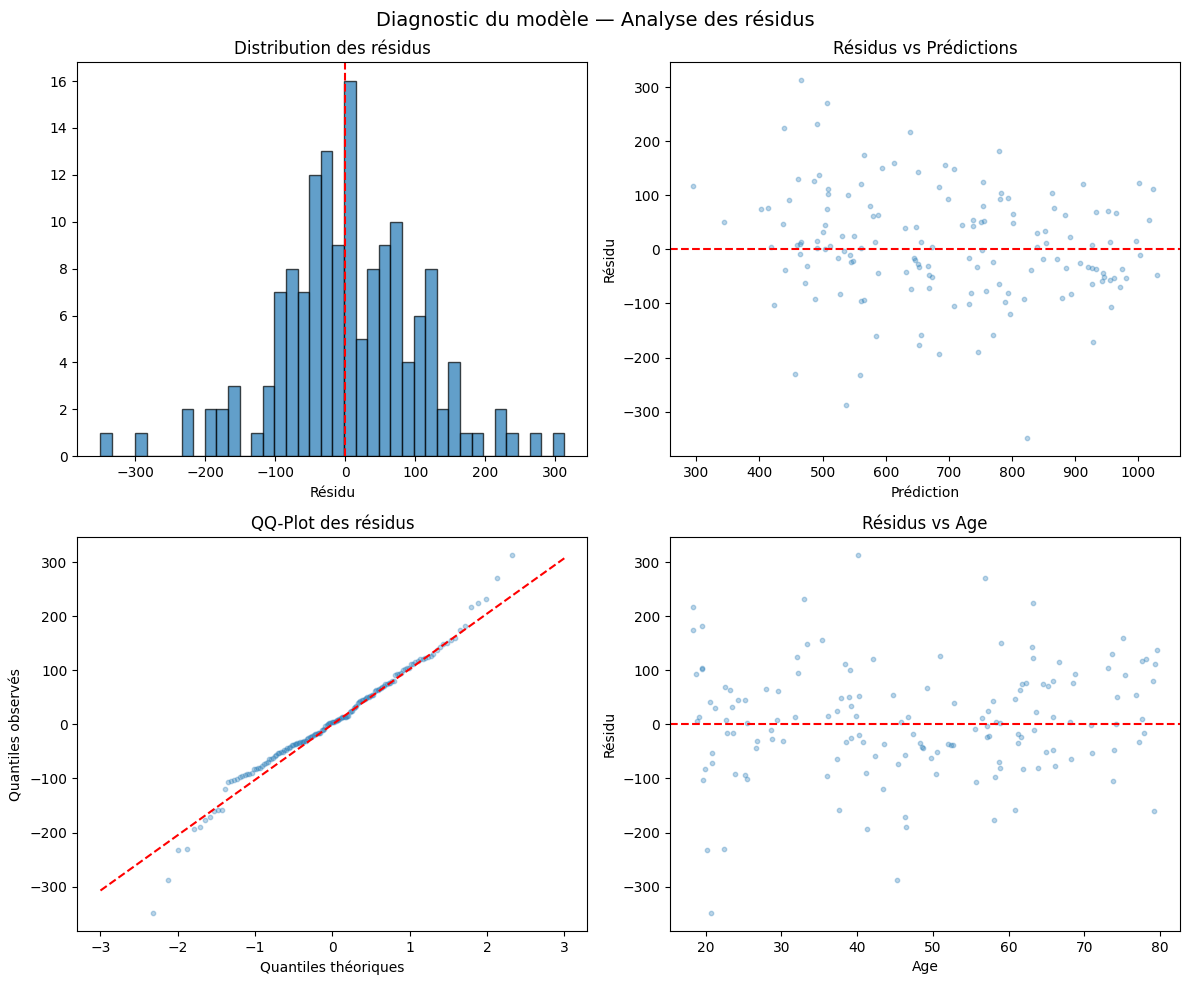

Résidus - Moyenne : 6.12 (devrait être ~0)
Résidus - Std     : 102.44
Résidus - Skewness: -0.17


In [8]:
# =============================================================
# PARTIE 6 : ANALYSE DES RÉSIDUS
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 6 : Diagnostic par les résidus")
print("=" * 60)

y_pred = best_pipe.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Distribution des résidus
axes[0, 0].hist(residuals, bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--')
axes[0, 0].set_title('Distribution des résidus')
axes[0, 0].set_xlabel('Résidu')

# 2. Résidus vs Prédictions
axes[0, 1].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_title('Résidus vs Prédictions')
axes[0, 1].set_xlabel('Prédiction')
axes[0, 1].set_ylabel('Résidu')

# 3. QQ-Plot (approximatif)
from scipy import stats
sorted_residuals = np.sort(residuals)
theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(residuals)))
axes[1, 0].scatter(theoretical_quantiles, sorted_residuals, alpha=0.3, s=10)
axes[1, 0].plot([-3, 3], [-3*residuals.std(), 3*residuals.std()], 'r--')
axes[1, 0].set_title('QQ-Plot des résidus')
axes[1, 0].set_xlabel('Quantiles théoriques')
axes[1, 0].set_ylabel('Quantiles observés')

# 4. Résidus vs Age (chercher un pattern non capté)
axes[1, 1].scatter(X_test['age'], residuals, alpha=0.3, s=10)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Résidus vs Age')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Résidu')

plt.suptitle('Diagnostic du modèle — Analyse des résidus', fontsize=14)
plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150)
plt.show()

print(f"Résidus - Moyenne : {residuals.mean():.2f} (devrait être ~0)")
print(f"Résidus - Std     : {residuals.std():.2f}")
print(f"Résidus - Skewness: {stats.skew(residuals):.2f}")



### 1. **Distribution des résidus (histogramme)**
- Les résidus doivent être **centrés autour de 0** (moyenne ≈ 0). C'est le cas si la médiane de l'histogramme coïncide avec la ligne rouge.
- Idéalement, la distribution doit être **approximativement symétrique et en forme de cloche** (distribution normale).
- **Si l'histogramme est asymétrique** (skewed) : le modèle commet des erreurs systématiques dans une direction (tend à surestimer ou sous-estimer).
- **Si la distribution est bimodale ou multimodale** : possible présence de sous-groupes dans les données que le modèle ne capture pas.

### 2. **Résidus vs Prédictions (scatter plot)**
- **Points dispersés aléatoirement autour de la ligne y=0** : bon signe ! Le modèle n'a pas de biais systématique.
- **Pattern en forme de cône** (augmentation de la variance avec la prédiction) : **hétéroscédasticité**. Les erreurs augmentent quand les prédictions augmentent → peut nécessiter une transformation de la variable target ou une pondération des observations.
- **Pattern en U ou autre forme** : le modèle a une erreur systématique non capturée (par ex., relation polynomiale oubliée).
- **Bandes horizontales** : peuvent indiquer des variables catégoriques cachées ou du bruit quantisé.

### 3. **QQ-Plot (Normal Probability Plot)**
- **Points proches de la diagonale rouge** : résidus qui suivent une distribution normale → hypothèse validée.
- **Écarts aux extrémités** : queue gauche ou droite plus lourde qu'une normale → présence d'outliers.
- **Écarts au centre** : loin de la normalité au centre → distribution des résidus non normale.
- **Courbe systématique loin de la diagonale** : peut indiquer une transformation de la target nécessaire (log, racine, etc.).

### 4. **Résidus vs Age (résidus vs feature importante)**
- **Points dispersés aléatoirement** : la variable est bien captée par le modèle.
- **Pattern systématique** (ex: courbe, cyclique) : **la relation avec cette variable n'est pas complètement linéaire/polynomiale**. Il manque un terme d'interaction ou une transformation supplémentaire.
- **Variance des résidus change avec Age** : hétéroscédasticité liée à cette variable (les jeunes conducteurs sont plus imprévisibles).
- **Résidus importants pour une plage d'âge donnée** : le modèle fonctionne moins bien pour ce segment.

---

**Conclusion** : Un bon diagnostic montre des résidus sans pattern, centrés à 0, de variance constante, et approximativement normaux. Tout écart suggère une amélioration : ajouter des features, changer la régularisation, ou transformer les données.


PARTIE 7 : Courbes d'apprentissage du modèle final


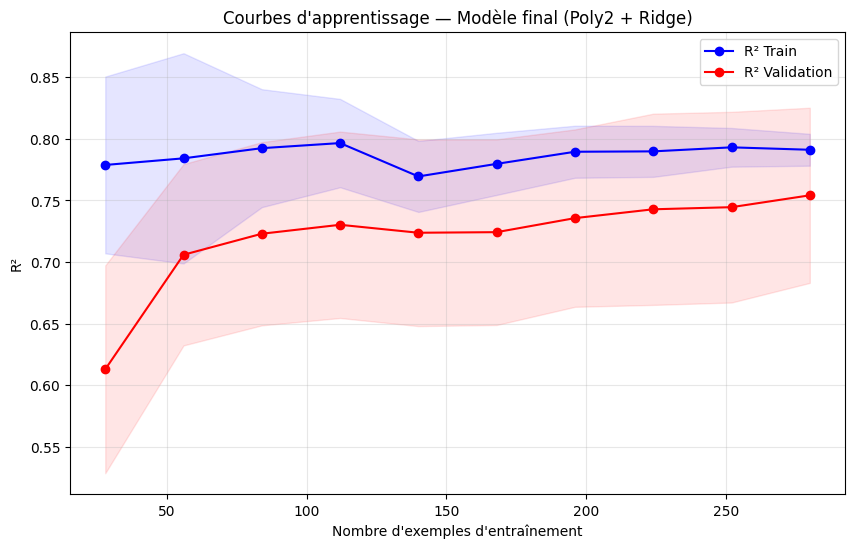

In [9]:
# =============================================================
# PARTIE 7 : COURBES D'APPRENTISSAGE DU MEILLEUR MODÈLE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 7 : Courbes d'apprentissage du modèle final")
print("=" * 60)

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', random_state=42
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'b-o', label='R² Train')
plt.fill_between(train_sizes, 
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), 
                 alpha=0.1, color='blue')
plt.plot(train_sizes, val_scores.mean(axis=1), 'r-o', label='R² Validation')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color='red')
plt.xlabel('Nombre d\'exemples d\'entraînement')
plt.ylabel('R²')
plt.title('Courbes d\'apprentissage — Modèle final (Poly2 + Ridge)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("learning_curve_final.png", dpi=150)
plt.show()

# TODO : Interpréter :
# 1. Le modèle souffre-t-il de biais ou de variance ?
# --> Variance
# 2. Plus de données aideraient-elles ?
#    ---> oui car les courbes convergent 
# 3. Le modèle a-t-il convergé ?
#    ---> ilcommence 

In [10]:
# =============================================================
# QUESTIONS FINALES
# =============================================================
"""
QUESTIONS DE SYNTHÈSE (à discuter en groupe) :

1. En quoi la régularisation est-elle liée au dilemme biais-variance ?
   → Plus d'alpha = plus de biais, moins de variance. C'est un curseur direct.

2. Quand utiliseriez-vous Lasso plutôt que Ridge en tarification ?
   → Quand vous avez beaucoup de variables candidates et que vous voulez 
     identifier les plus pertinentes automatiquement. Le Lasso fait de la 
     sélection de variables native.

3. Un modèle parfait sur le train mais médiocre sur le test : que faites-vous ?
   → Diagnostic : overfitting (haute variance).
     Actions : plus de régularisation (augmenter alpha), réduire le degré 
     polynomial, ou utiliser plus de données.

4. Votre DG vous demande "pourquoi ce client paie plus cher" : quel modèle ?
   → Un modèle interprétable ! GLM (odds ratios), ou régression linéaire 
     (coefficients). Si vous avez un GBM, utilisez SHAP pour expliquer 
     les prédictions individuelles.

5. Vous avez un R² de 0.65 avec votre meilleur modèle. Est-ce suffisant ?
   → Ça dépend du contexte ! En tarification auto, un R² de 0.65 sur les 
     coûts individuels est EXCELLENT (beaucoup de bruit irréductible).
     La vraie question est : est-ce mieux que le modèle actuel en production ?
"""


'\nQUESTIONS DE SYNTHÈSE (à discuter en groupe) :\n\n1. En quoi la régularisation est-elle liée au dilemme biais-variance ?\n   → Plus d\'alpha = plus de biais, moins de variance. C\'est un curseur direct.\n\n2. Quand utiliseriez-vous Lasso plutôt que Ridge en tarification ?\n   → Quand vous avez beaucoup de variables candidates et que vous voulez \n     identifier les plus pertinentes automatiquement. Le Lasso fait de la \n     sélection de variables native.\n\n3. Un modèle parfait sur le train mais médiocre sur le test : que faites-vous ?\n   → Diagnostic : overfitting (haute variance).\n     Actions : plus de régularisation (augmenter alpha), réduire le degré \n     polynomial, ou utiliser plus de données.\n\n4. Votre DG vous demande "pourquoi ce client paie plus cher" : quel modèle ?\n   → Un modèle interprétable ! GLM (odds ratios), ou régression linéaire \n     (coefficients). Si vous avez un GBM, utilisez SHAP pour expliquer \n     les prédictions individuelles.\n\n5. Vous avez 